# 20. Derin MLP ile Bina Isıtma Yükü

**Kategori:** Derin Öğrenme  
**Gerçek veri seti:** UCI Energy Efficiency  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/242/energy+efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency)  
**Amaç:** Bina geometrisi ve camlama özelliklerinden ısıtma yükünü tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Gerçek enerji verisi EDA'sı

In [2]:
df = pd.read_csv(DATA_DIR / "energy_efficiency.csv")
display(df.head())
print("Boyut:", df.shape, "| Eksik:", int(df.isna().sum().sum()), "| Tekrar:", df.duplicated().sum())
display(df.describe().T.round(2))

Boyut: (768, 10) | Eksik: 0 | Tekrar: 0


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


,count,mean,std,min,25%,50%,75%,max
relative_compactness,768.0,0.76,0.11,0.62,0.68,0.75,0.83,0.98
surface_area,768.0,671.71,88.09,514.50,606.38,673.75,741.12,808.50
wall_area,768.0,318.50,43.63,245.00,294.00,318.50,343.00,416.50
roof_area,768.0,176.60,45.17,110.25,140.88,183.75,220.50,220.50
overall_height,768.0,5.25,1.75,3.50,3.50,5.25,7.00,7.00
orientation,768.0,3.50,1.12,2.00,2.75,3.50,4.25,5.00
glazing_area,768.0,0.23,0.13,0.00,0.10,0.25,0.40,0.40
glazing_area_distribution,768.0,2.81,1.55,0.00,1.75,3.00,4.00,5.00
heating_load,768.0,22.31,10.09,6.01,12.99,18.95,31.67,43.10
cooling_load,768.0,24.59,9.51,10.90,15.62,22.08,33.13,48.03


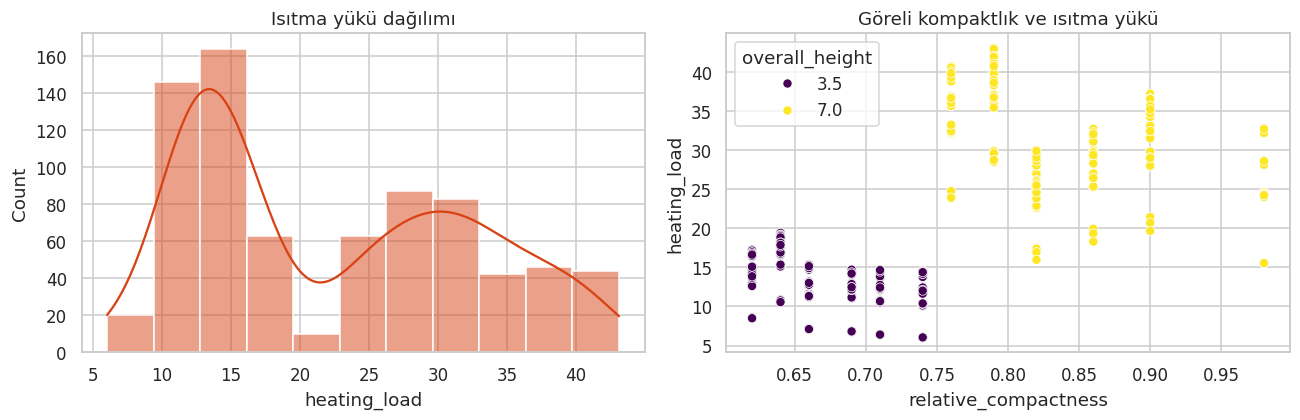

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.heating_load, kde=True, ax=axes[0], color="#D84315")
axes[0].set(title="Isıtma yükü dağılımı")
sns.scatterplot(data=df, x="relative_compactness", y="heating_load",
                hue="overall_height", palette="viridis", ax=axes[1])
axes[1].set(title="Göreli kompaktlık ve ısıtma yükü")
plt.tight_layout(); plt.show()

## 2. Baseline ve derin sinir ağı

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["heating_load", "cooling_load"])
y = df.heating_load
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20,
                                                    random_state=RANDOM_STATE)
mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation="relu",
                 batch_size=32, learning_rate_init=.001, max_iter=1000,
                 early_stopping=True, validation_fraction=.15,
                 n_iter_no_change=25, random_state=RANDOM_STATE)
).fit(X_train, y_train)
baseline = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                 random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
fitted = {"Derin MLP": mlp, "Random Forest baseline": baseline}
preds = {name: model.predict(X_test) for name, model in fitted.items()}
scores = pd.DataFrame({name: {"MAE": mean_absolute_error(y_test, pred),
                              "RMSE": root_mean_squared_error(y_test, pred),
                              "R2": r2_score(y_test, pred)}
                       for name, pred in preds.items()}).T.sort_values("MAE")
display(scores.round(3))

,MAE,RMSE,R2
Random Forest baseline,0.356,0.505,0.998
Derin MLP,0.450,0.633,0.996


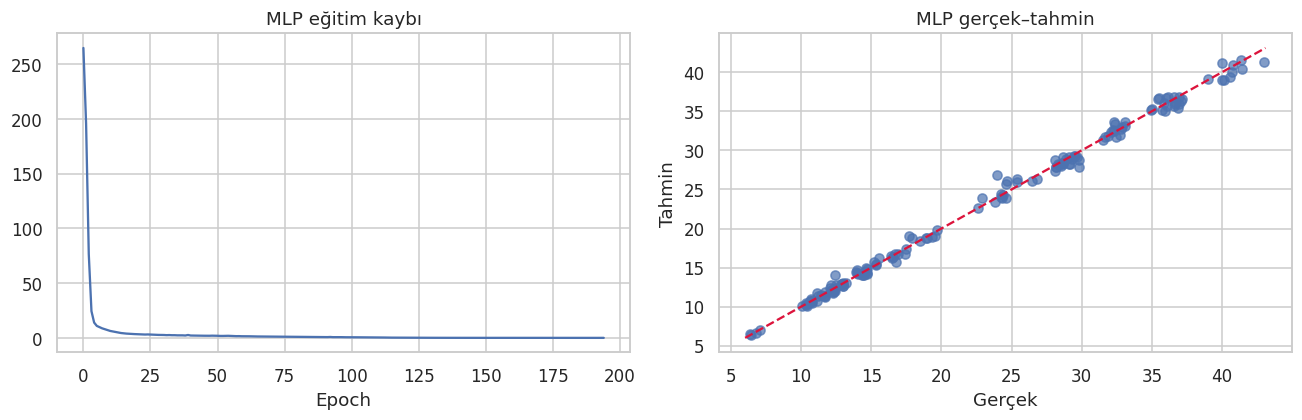

In [5]:
mlp_core = mlp.named_steps["mlpregressor"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp_core.loss_curve_); axes[0].set(title="MLP eğitim kaybı", xlabel="Epoch")
axes[1].scatter(y_test, preds["Derin MLP"], alpha=.7)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], "--", c="crimson")
axes[1].set(title="MLP gerçek–tahmin", xlabel="Gerçek", ylabel="Tahmin")
plt.tight_layout(); plt.show()

best_name = scores.index[0]
joblib.dump({"best_name": best_name, "best_model": fitted[best_name],
             "all_models": fitted, "mlp_model": mlp, "features": X.columns.tolist(),
             "metrics": scores.to_dict()}, MODEL_DIR / "20_enerji_yuku.joblib")
json.dump({"best_model": best_name, "mlp_epochs": int(mlp_core.n_iter_),
           **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "20_enerji_yuku.json", "w"), indent=2)

## Sonuç

MLP üç gizli katman, ölçekleme, doğrulama ayrımı ve erken durdurmayla kuruldu. Ağaç tabanlı güçlü bir
baseline karşısında değerlendirilmesi, sinir ağının gerçekten ek değer sağlayıp sağlamadığını gösterir.
En iyi model ayrı tutulurken iki eğitilmiş model de aynı artifact içinde kaydedildi.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **sinir ağıyla sayısal tahmin** biçimindedir.
Bu notebookta **768 gerçek bina simülasyonu, derin mimari, güçlü baseline, öğrenme eğrisi ve üç regresyon metriği** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).